In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [4]:
plot_df = pd.read_csv('/seq/epiprod02/etorlait/p16/From_Abhishek/plot_df.csv')
plot_df

,Gene,full_id,expression,Donor,Tissue,log_expr,Age_group
0,MTAP,GTEX-1117F-0226-SM-5GZZ7,6.7020,GTEX-1117F,Adipose - Subcutaneous,2.041480,"(60, 70]"
1,CDKN2A,GTEX-1117F-0226-SM-5GZZ7,1.8730,GTEX-1117F,Adipose - Subcutaneous,1.055357,"(60, 70]"
2,CDKN2B-AS1,GTEX-1117F-0226-SM-5GZZ7,0.3826,GTEX-1117F,Adipose - Subcutaneous,0.323966,"(60, 70]"
3,CDKN2B,GTEX-1117F-0226-SM-5GZZ7,15.9700,GTEX-1117F,Adipose - Subcutaneous,2.831447,"(60, 70]"
4,DMRTA1,GTEX-1117F-0226-SM-5GZZ7,0.3353,GTEX-1117F,Adipose - Subcutaneous,0.289156,"(60, 70]"
...,...,...,...,...,...,...,...
121669,CDKN2B-AS1,GTEX-ZZPU-2726-SM-5NQ8O,0.1166,GTEX-ZZPU,Adipose - Subcutaneous,0.110288,"(40, 50]"
121670,CDKN2B,GTEX-ZZPU-2726-SM-5NQ8O,73.4800,GTEX-ZZPU,Adipose - Subcutaneous,4.310531,"(40, 50]"
121671,DMRTA1,GTEX-ZZPU-2726-SM-5NQ8O,1.7460,GTEX-ZZPU,Adipose - Subcutaneous,1.010145,"(40, 50]"
121672,CDKN2A-p14,GTEX-ZZPU-2726-SM-5NQ8O,0.3000,GTEX-ZZPU,Adipose - Subcutaneous,0.262364,"(40, 50]"


In [5]:
plot_df["Age_group"].value_counts()

(60, 70]    41636
(50, 60]    38332
(40, 50]    21448
(30, 40]    10087
(20, 30]     9982
Name: Age_group, dtype: int64

In [6]:
plot_df_subs=plot_df[plot_df["Age_group"].isin(['(20, 30]','(30, 40]', '(40, 50]', '(50, 60]', '(60, 70]'])]
plot_df_subs2=plot_df_subs[plot_df_subs["Gene"].isin(['MTAP', 'CDKN2A', 'CDKN2A-p16', 'CDKN2A-p14', 'CDKN2B', 'CDKN2B-AS1'])]

In [7]:
geneorder=['MTAP', 'CDKN2A', 'CDKN2A-p16', 'CDKN2A-p14', 'CDKN2B', 'CDKN2B-AS1']
ageorder = ['(20, 30]','(30, 40]', '(40, 50]', '(50, 60]', '(60, 70]']

plot_df_subs2["Gene"] = pd.Categorical(plot_df_subs2["Gene"], categories=geneorder, ordered=True)
plot_df_subs2["Age_group"] = pd.Categorical(plot_df_subs2["Age_group"], categories=ageorder, ordered=True)


/local/scratch/58031962.1.broad/ipykernel_76476/4029242643.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df_subs2["Gene"] = pd.Categorical(plot_df_subs2["Gene"], categories=geneorder, ordered=True)
/local/scratch/58031962.1.broad/ipykernel_76476/4029242643.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df_subs2["Age_group"] = pd.Categorical(plot_df_subs2["Age_group"], categories=ageorder, ordered=True)


In [8]:
plot_df_subs2.Tissue.value_counts()

Muscle - Skeletal                            4812
Whole Blood                                  4524
Skin - Sun Exposed (Lower leg)               4206
Adipose - Subcutaneous                       3978
Artery - Tibial                              3972
Thyroid                                      3912
Nerve - Tibial                               3708
Skin - Not Sun Exposed (Suprapubic)          3618
Lung                                         3468
Esophagus - Mucosa                           3324
Adipose - Visceral (Omentum)                 3246
Esophagus - Muscularis                       3084
Cells - Cultured fibroblasts                 3018
Breast - Mammary Tissue                      2754
Artery - Aorta                               2592
Heart - Left Ventricle                       2586
Heart - Atrial Appendage                     2568
Colon - Transverse                           2436
Esophagus - Gastroesophageal Junction        2244
Colon - Sigmoid                              2232


In [9]:
mypalette = {
    "(20, 30]": "#c6dbef",
    "(30, 40]": "#9ecae1",
    "(40, 50]": "#6baed6",
    "(50, 60]": "#3182bd",
    "(60, 70]": "#08519c" }

mypalette1 = ["#c6dbef",
              "#9ecae1",
              "#6baed6",
              "#3182bd",
              "#08519c" ]

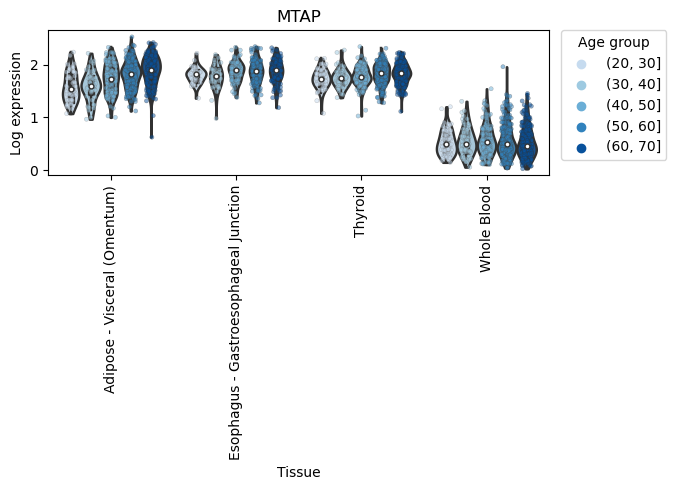

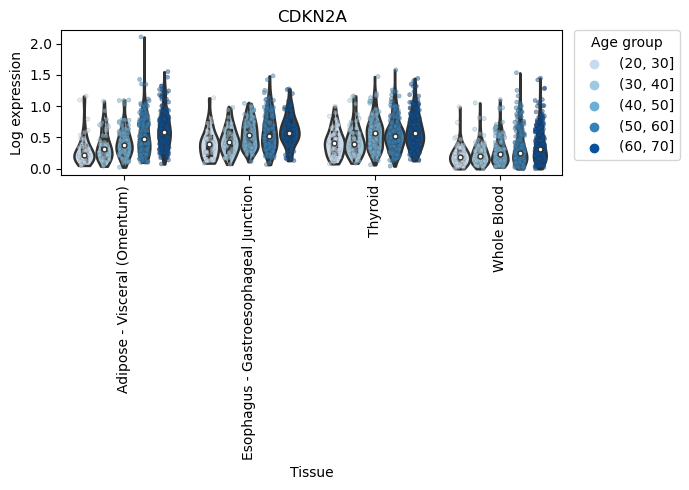

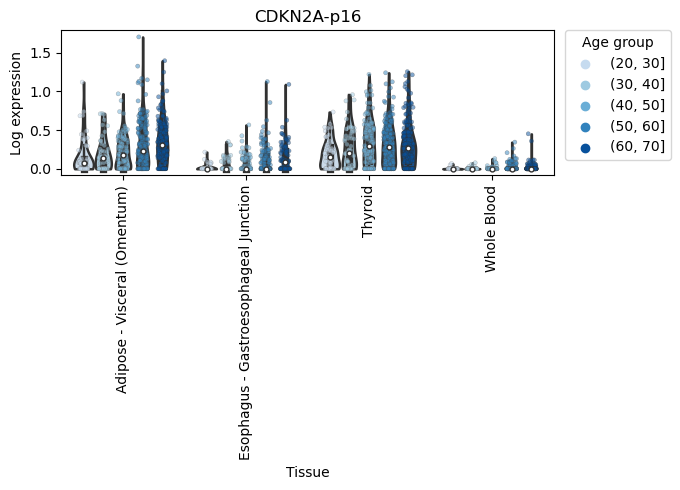

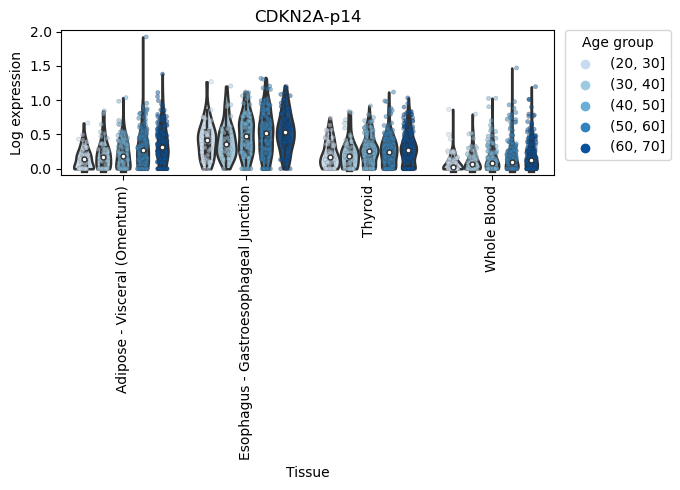

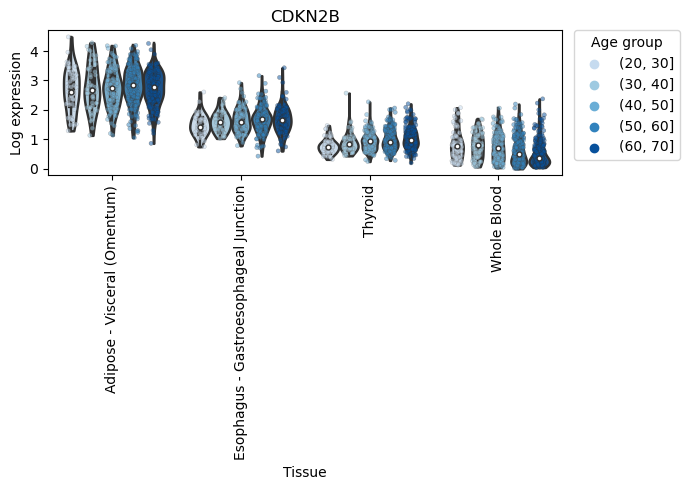

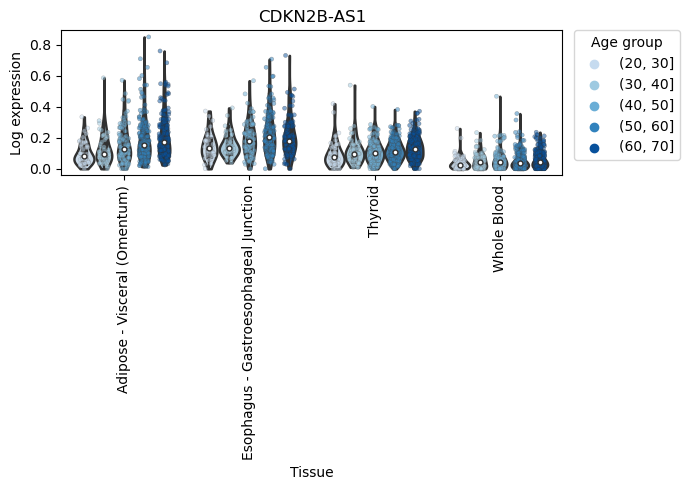

In [10]:
main_tissue = ['Adipose - Visceral (Omentum)',
               'Esophagus - Gastroesophageal Junction', 
               'Thyroid',
               'Whole Blood']

plot_df_subs3=plot_df_subs2[plot_df_subs2["Tissue"].isin(main_tissue)].copy()
plot_df_subs3["Tissue"] = plot_df_subs3["Tissue"].astype("category").cat.remove_unused_categories()

#mypalette1 = ["#4C72B0", "#8172B3"]
#mypalette = {
#    "(20, 30]": "#c5d1e5",
#    "(60, 70]": "#dfdbec"
#}

for this_gene in geneorder:
    nrows, ncols = 1, 1
#    fig = plt.figure(figsize=(4, 5))
    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_subplot(1, 1, 1)

    # Subset for this gene
    temp = plot_df_subs3[plot_df_subs3.Gene == this_gene].copy()

    # Stripplot (individual dots)
    sns.stripplot(
        x="Tissue", y="log_expr", hue="Age_group", data=temp,
        order=main_tissue, hue_order=ageorder, palette=mypalette1,
        jitter=0.2, size=3, dodge=True, alpha=0.5, linewidth=0.3,
        edgecolor="gray", ax=ax
    )

    # Violin plot 
    sns.violinplot(
        x="Tissue", y="log_expr", hue="Age_group", data=temp,
        order=main_tissue, hue_order=ageorder, palette=mypalette,
        dodge=True, cut=0, linewidth=1.75, alpha=0.01, ax=ax
    )

    # Title/ axis labels
    ax.set_title(this_gene)
    ax.set_ylabel("Log expression")
    for label in ax.get_xticklabels():
        label.set_rotation(90)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[0:len(ageorder)],
        labels[0:len(ageorder)],
        title="Age group",
        bbox_to_anchor=(1.01, 1.05),
        loc="upper left"
    )

    fig.tight_layout()
    plt.show()
    #fig.savefig(os.path.join('plots', "viostripplot_2groups_MainT_" + this_gene +'_AllAgeGroups_longer.pdf'), format='pdf')

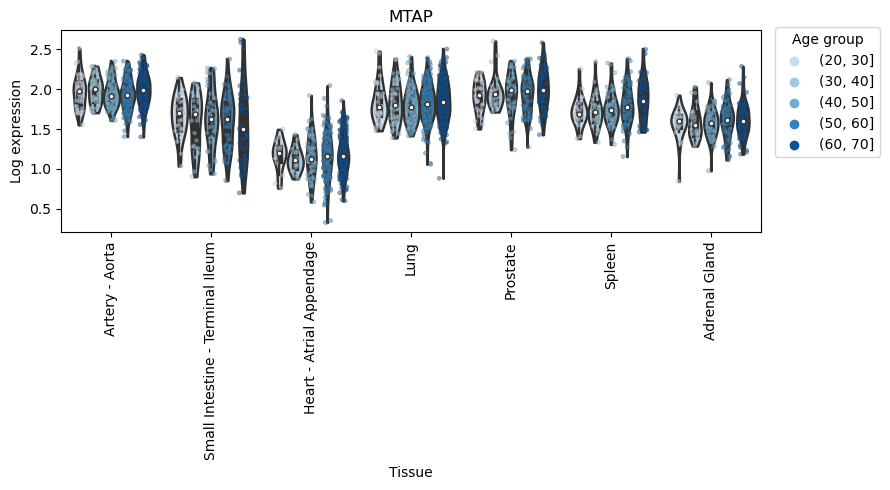

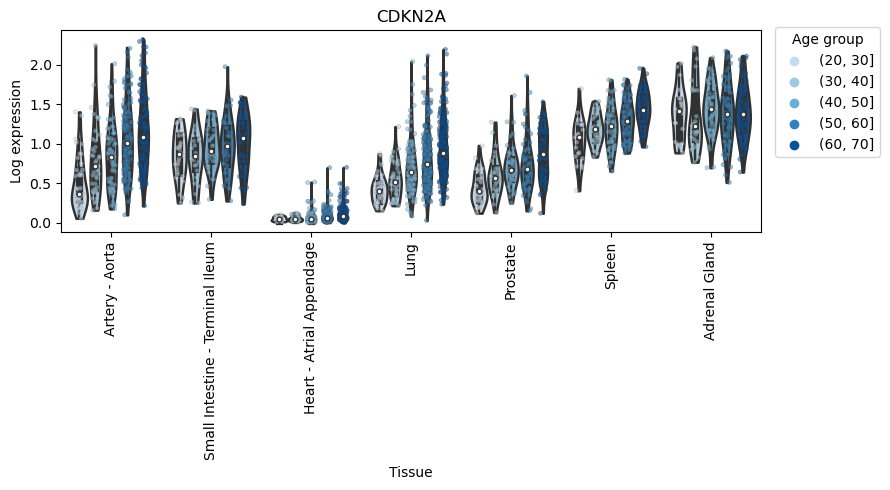

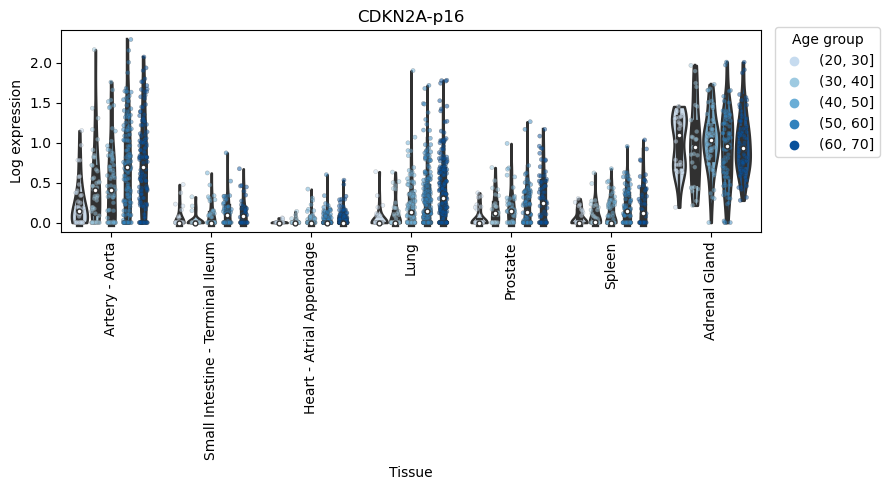

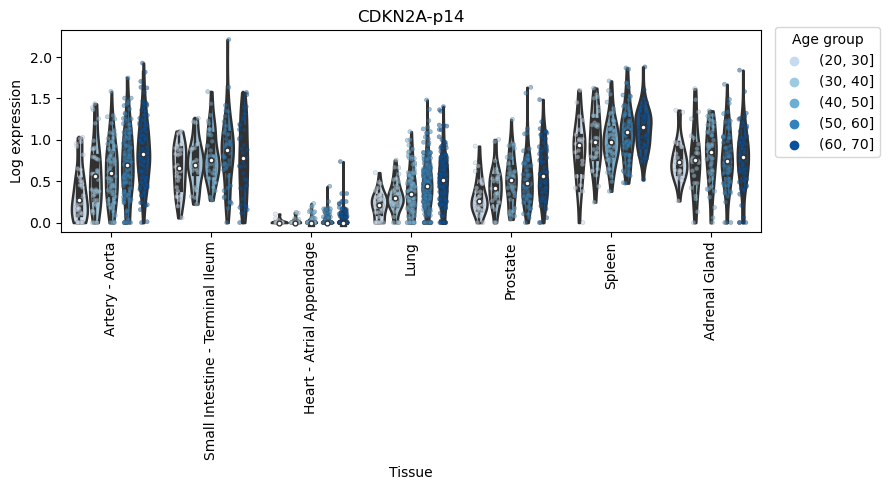

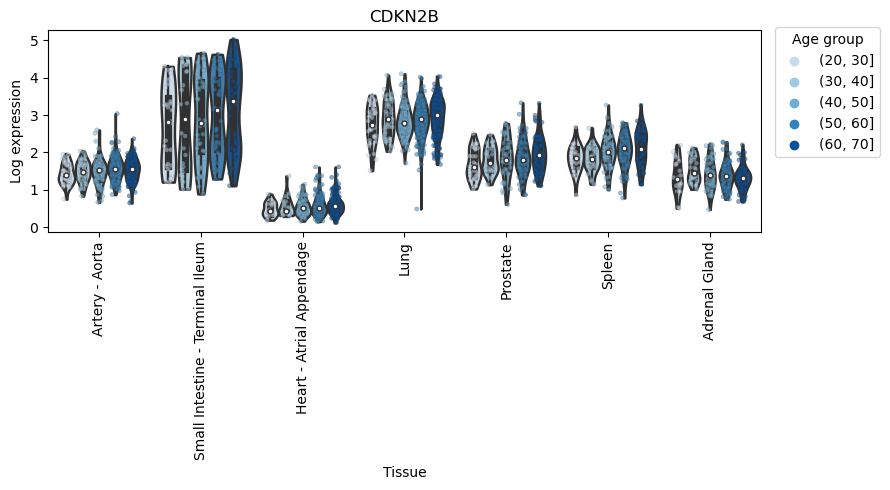

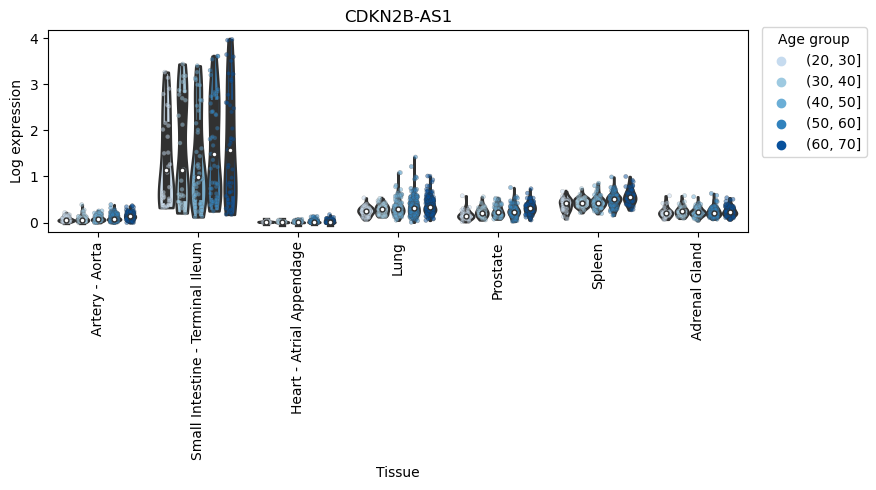

In [11]:
supp_tissue = ['Artery - Aorta',
               'Small Intestine - Terminal Ileum',
               'Heart - Atrial Appendage',
               'Lung',
               'Prostate',
               'Spleen',
               'Adrenal Gland']

plot_df_subs4=plot_df_subs2[plot_df_subs2["Tissue"].isin(supp_tissue)].copy()
plot_df_subs4["Tissue"] = plot_df_subs4["Tissue"].astype("category").cat.remove_unused_categories()


for this_gene in geneorder:
    nrows, ncols = 1, 1
#    fig = plt.figure(figsize=(7, 5))
    fig = plt.figure(figsize=(9, 5))
    ax = fig.add_subplot(1, 1, 1)

    # Subset for this gene
    temp = plot_df_subs4[plot_df_subs4.Gene == this_gene].copy()

    # Stripplot (individual dots)
    sns.stripplot(
        x="Tissue", y="log_expr", hue="Age_group", data=temp,
        order=supp_tissue, hue_order=ageorder, palette=mypalette1,
        jitter=0.2, size=3, dodge=True, alpha=0.5, linewidth=0.3,
        edgecolor="gray", ax=ax
    )

    # Violin plot 
    sns.violinplot(
        x="Tissue", y="log_expr", hue="Age_group", data=temp,
        order=supp_tissue, hue_order=ageorder, palette=mypalette,
        dodge=True, cut=0, linewidth=1.75, alpha=0.01, ax=ax
    )

    # Title/ axis labels
    ax.set_title(this_gene)
    ax.set_ylabel("Log expression")
    for label in ax.get_xticklabels():
        label.set_rotation(90)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[0:len(ageorder)],
        labels[0:len(ageorder)],
        title="Age group",
        bbox_to_anchor=(1.01, 1.05),
        loc="upper left"
    )

    fig.tight_layout()
    plt.show()
    #fig.savefig(os.path.join('plots', "viostripplot_2groups_SuppT_" + this_gene +'_AllAgeGroups_longer.pdf'), format='pdf')

In [12]:
temp

,Gene,full_id,expression,Donor,Tissue,log_expr,Age_group
30,CDKN2B-AS1,GTEX-1117F-0726-SM-5GIEN,0.09348,GTEX-1117F,Heart - Atrial Appendage,0.089365,"(60, 70]"
86,CDKN2B-AS1,GTEX-111CU-0126-SM-5GZWZ,0.12160,GTEX-111CU,Adrenal Gland,0.114756,"(50, 60]"
100,CDKN2B-AS1,GTEX-111CU-0326-SM-5GZXO,0.34550,GTEX-111CU,Lung,0.296766,"(50, 60]"
107,CDKN2B-AS1,GTEX-111CU-0426-SM-5GZY1,0.18630,GTEX-111CU,Spleen,0.170839,"(50, 60]"
170,CDKN2B-AS1,GTEX-111CU-1326-SM-5NQ8L,1.17600,GTEX-111CU,Small Intestine - Terminal Ileum,0.777488,"(50, 60]"
...,...,...,...,...,...,...,...
121536,CDKN2B-AS1,GTEX-ZZPU-0126-SM-5E446,0.25250,GTEX-ZZPU,Spleen,0.225142,"(40, 50]"
121543,CDKN2B-AS1,GTEX-ZZPU-0226-SM-5N9BV,0.24420,GTEX-ZZPU,Artery - Aorta,0.218493,"(40, 50]"
121564,CDKN2B-AS1,GTEX-ZZPU-0526-SM-5E44U,0.26650,GTEX-ZZPU,Lung,0.236257,"(40, 50]"
121606,CDKN2B-AS1,GTEX-ZZPU-1126-SM-5N9CW,0.01583,GTEX-ZZPU,Heart - Atrial Appendage,0.015706,"(40, 50]"


In [13]:
temp.groupby("Age_group")["Donor"].nunique()

Age_group
(20, 30]     77
(30, 40]     71
(40, 50]    150
(50, 60]    263
(60, 70]    272
Name: Donor, dtype: int64

In [14]:
all_my_tissues_of_interest = ['Adipose - Visceral (Omentum)', 
                       'Artery - Aorta',
                       'Small Intestine - Terminal Ileum', 
                       'Esophagus - Gastroesophageal Junction', 
                       'Heart - Atrial Appendage',
                       'Lung', 
                      'Prostate', 
                      'Spleen', 
                      'Thyroid', 
                      'Whole Blood', 
                      'Adrenal Gland']


In [15]:
from scipy import stats
pd.reset_option('display.float_format')

### first tissue: Adipose - Visceral (Omentum) 
tissue='Adipose - Visceral (Omentum)'
print(tissue)
results = []

for gene, subset in plot_df_subs2[plot_df_subs2.Tissue == 'Adipose - Visceral (Omentum)'].groupby("Gene"):
    group1 = subset.loc[subset["Age_group"] == "(20, 30]", "log_expr"]
    group2 = subset.loc[subset["Age_group"] == "(60, 70]", "log_expr"]
    

    t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=False)  # Welch’s t-test
    
    results.append({
        "gene name": gene,
        "p_value": p_val,
        "mean_20-30": group1.mean(),
        "mean_60-70": group2.mean(),
        "n_20-30": len(group1),
        "n_60-70": len(group2),

    })

print ("")
print ("n of (20, 30]", len(group1))
print ("n of (60, 70]",  len(group2))
print ("")
print (subset["Age_group"].value_counts(sort=False))
print ("")

results_df = pd.DataFrame(results)
results_df.insert(0, "tissue", tissue)

#print(results_df)


Adipose - Visceral (Omentum)

n of (20, 30] 49
n of (60, 70] 169

(20, 30]     49
(30, 40]     47
(40, 50]    101
(50, 60]    175
(60, 70]    169
Name: Age_group, dtype: int64



In [16]:
len(group1)

49

In [17]:
tissues_of_interest = ['Artery - Aorta',
                       'Small Intestine - Terminal Ileum', 
                       'Esophagus - Gastroesophageal Junction', 
                       'Heart - Atrial Appendage',
                       'Lung', 
                      'Prostate', 
                      'Spleen', 
                      'Thyroid', 
                      'Whole Blood', 
                      'Adrenal Gland']

### Loop to go through the rest of the tissues

for this_tissue in tissues_of_interest:

    print(this_tissue)
    results = []

    for gene, subset in plot_df_subs2[plot_df_subs2.Tissue == this_tissue].copy().groupby("Gene"):
        group1 = subset.loc[subset["Age_group"] == "(20, 30]", "log_expr"]
        group2 = subset.loc[subset["Age_group"] == "(60, 70]", "log_expr"]
    

        t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=False)  # Welch’s t-test
    
        results.append({
            "gene name": gene,
            "p_value": p_val,
            "mean_20-30": group1.mean(),
            "mean_60-70": group2.mean(),
            "n_20-30": len(group1),
            "n_60-70": len(group2),

        })

    print ("")
    print ("n of (20, 30]", len(group1))
    print ("n of (60, 70]",  len(group2))
    print ("")
    print (subset["Age_group"].value_counts(sort=False))
    print ("")

    results_df_temp = pd.DataFrame(results)
    results_df_temp.insert(0, "tissue", this_tissue)

    results_df = pd.concat([results_df, results_df_temp])

    #print(results_df)

Artery - Aorta

n of (20, 30] 40
n of (60, 70] 131

(20, 30]     40
(30, 40]     43
(40, 50]     75
(50, 60]    143
(60, 70]    131
Name: Age_group, dtype: int64

Small Intestine - Terminal Ileum

n of (20, 30] 28
n of (60, 70] 43

(20, 30]    28
(30, 40]    26
(40, 50]    41
(50, 60]    49
(60, 70]    43
Name: Age_group, dtype: int64

Esophagus - Gastroesophageal Junction

n of (20, 30] 35
n of (60, 70] 97

(20, 30]     35
(30, 40]     36
(40, 50]     80
(50, 60]    126
(60, 70]     97
Name: Age_group, dtype: int64

Heart - Atrial Appendage

n of (20, 30] 16
n of (60, 70] 169

(20, 30]     16
(30, 40]     21
(40, 50]     70
(50, 60]    152
(60, 70]    169
Name: Age_group, dtype: int64

Lung

n of (20, 30] 37
n of (60, 70] 196

(20, 30]     37
(30, 40]     44
(40, 50]    107
(50, 60]    194
(60, 70]    196
Name: Age_group, dtype: int64

Prostate

n of (20, 30] 32
n of (60, 70] 70

(20, 30]    32
(30, 40]    27
(40, 50]    44
(50, 60]    72
(60, 70]    70
Name: Age_group, dtype: int64



In [18]:
results_df

,tissue,gene name,p_value,mean_20-30,mean_60-70,n_20-30,n_60-70
0,Adipose - Visceral (Omentum),MTAP,4.818967e-09,1.587531,1.886466,49,169
1,Adipose - Visceral (Omentum),CDKN2A,3.666113e-13,0.298196,0.634943,49,169
2,Adipose - Visceral (Omentum),CDKN2A-p16,3.365277e-05,0.162655,0.337626,49,169
3,Adipose - Visceral (Omentum),CDKN2A-p14,3.140264e-10,0.149120,0.358148,49,169
4,Adipose - Visceral (Omentum),CDKN2B,5.506797e-01,2.660786,2.727959,49,169
...,...,...,...,...,...,...,...
1,Adrenal Gland,CDKN2A,8.788792e-01,1.378228,1.390497,22,76
2,Adrenal Gland,CDKN2A-p16,8.982850e-01,0.990527,0.979521,22,76
3,Adrenal Gland,CDKN2A-p14,7.781055e-01,0.756332,0.775340,22,76
4,Adrenal Gland,CDKN2B,7.152391e-01,1.349492,1.311933,22,76


In [19]:
from statsmodels.stats.multitest import multipletests

results_df["p_adj_fdr_bh"] = multipletests(results_df["p_value"], method="fdr_bh")[1]
results_df["p_adj_fdr_bh_float"] = results_df["p_adj_fdr_bh"].map(lambda x: f"{x:.6f}")
results_df["p_adj_fdr_bh_significant"] = results_df["p_adj_fdr_bh"]<0.05

results_df["p_adj_bonferroni"] = multipletests(results_df["p_value"], method="bonferroni")[1]
results_df["p_adj_bonferroni_float"] = results_df["p_adj_bonferroni"].map(lambda x: f"{x:.6f}")
results_df["p_adj_bonferroni_significant"] = results_df["p_adj_bonferroni"]<0.05


print(results_df)

                          tissue   gene name       p_value  mean_20-30  \
0   Adipose - Visceral (Omentum)        MTAP  4.818967e-09    1.587531   
1   Adipose - Visceral (Omentum)      CDKN2A  3.666113e-13    0.298196   
2   Adipose - Visceral (Omentum)  CDKN2A-p16  3.365277e-05    0.162655   
3   Adipose - Visceral (Omentum)  CDKN2A-p14  3.140264e-10    0.149120   
4   Adipose - Visceral (Omentum)      CDKN2B  5.506797e-01    2.660786   
..                           ...         ...           ...         ...   
1                  Adrenal Gland      CDKN2A  8.788792e-01    1.378228   
2                  Adrenal Gland  CDKN2A-p16  8.982850e-01    0.990527   
3                  Adrenal Gland  CDKN2A-p14  7.781055e-01    0.756332   
4                  Adrenal Gland      CDKN2B  7.152391e-01    1.349492   
5                  Adrenal Gland  CDKN2B-AS1  4.872788e-01    0.229120   

    mean_60-70  n_20-30  n_60-70  p_adj_fdr_bh p_adj_fdr_bh_float  \
0     1.886466       49      169  2.607519

In [20]:
results_df

,tissue,gene name,p_value,mean_20-30,mean_60-70,n_20-30,n_60-70,p_adj_fdr_bh,p_adj_fdr_bh_float,p_adj_fdr_bh_significant,p_adj_bonferroni,p_adj_bonferroni_float,p_adj_bonferroni_significant
0,Adipose - Visceral (Omentum),MTAP,4.818967e-09,1.587531,1.886466,49,169,2.607519e-08,0.000000,True,3.180518e-07,0.000000,True
1,Adipose - Visceral (Omentum),CDKN2A,3.666113e-13,0.298196,0.634943,49,169,4.839269e-12,0.000000,True,2.419634e-11,0.000000,True
2,Adipose - Visceral (Omentum),CDKN2A-p16,3.365277e-05,0.162655,0.337626,49,169,7.998660e-05,0.000080,True,2.221083e-03,0.002221,True
3,Adipose - Visceral (Omentum),CDKN2A-p14,3.140264e-10,0.149120,0.358148,49,169,2.072574e-09,0.000000,True,2.072574e-08,0.000000,True
4,Adipose - Visceral (Omentum),CDKN2B,5.506797e-01,2.660786,2.727959,49,169,6.160146e-01,0.616015,False,1.000000e+00,1.000000,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,Adrenal Gland,CDKN2A,8.788792e-01,1.378228,1.390497,22,76,9.063442e-01,0.906344,False,1.000000e+00,1.000000,False
2,Adrenal Gland,CDKN2A-p16,8.982850e-01,0.990527,0.979521,22,76,9.121047e-01,0.912105,False,1.000000e+00,1.000000,False
3,Adrenal Gland,CDKN2A-p14,7.781055e-01,0.756332,0.775340,22,76,8.283058e-01,0.828306,False,1.000000e+00,1.000000,False
4,Adrenal Gland,CDKN2B,7.152391e-01,1.349492,1.311933,22,76,7.738652e-01,0.773865,False,1.000000e+00,1.000000,False


In [21]:
results_df.p_adj_fdr_bh_significant.value_counts()

True     42
False    24
Name: p_adj_fdr_bh_significant, dtype: int64

In [22]:
results_df.p_adj_bonferroni_significant.value_counts()

False    37
True     29
Name: p_adj_bonferroni_significant, dtype: int64

In [23]:
#results_df.to_csv(os.path.join('plots', "viostripplot_2groups_GTEx_pvals_redone.txt"), sep='\t')

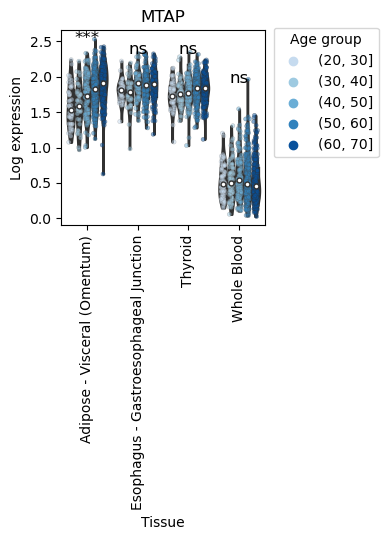

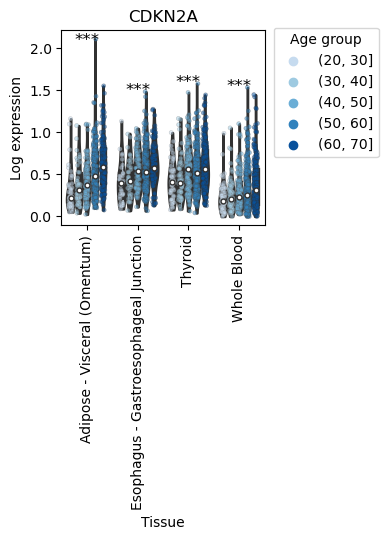

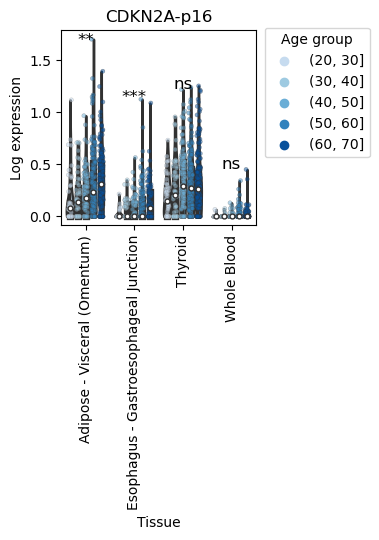

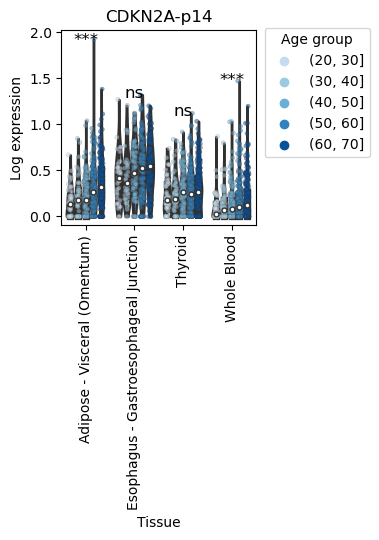

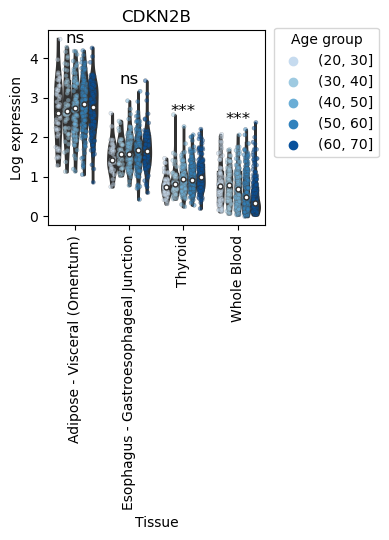

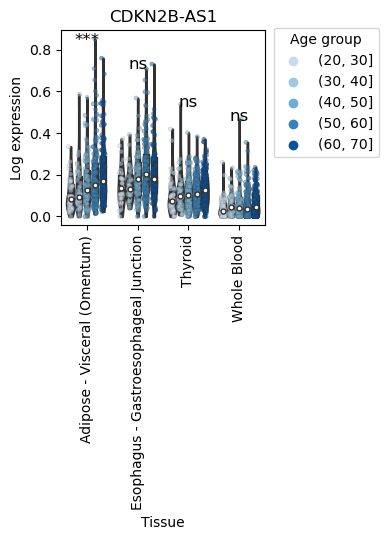

In [24]:
for this_gene in geneorder:
    nrows, ncols = 1, 1
    fig = plt.figure(figsize=(4, 5.5))
    ax = fig.add_subplot(1, 1, 1)

    temp = plot_df_subs3[plot_df_subs3.Gene == this_gene].copy()

    sns.stripplot(
        x="Tissue", y="log_expr", hue="Age_group", data=temp,
        order=main_tissue, hue_order=ageorder, palette=mypalette1,
        jitter=0.2, size=3, dodge=True, alpha=0.5, linewidth=0.3,
        edgecolor="gray", ax=ax
    )

    sns.violinplot(
        x="Tissue", y="log_expr", hue="Age_group", data=temp,
        order=main_tissue, hue_order=ageorder, palette=mypalette,
        dodge=True, cut=0, linewidth=1.75, alpha=0.01, ax=ax
    )

    # Annotate each tissue 
    for tissue in main_tissue:
        temp_tissue = temp[temp["Tissue"] == tissue]
        row = results_df[
            (results_df["gene name"] == this_gene) &
            (results_df["tissue"] == tissue)
        ]

        pval = row["p_adj_bonferroni"].values[0]
        # Convert p-value to stars
        if pval < 0.001:
            star = "***"
        elif pval < 0.01:
            star = "**"
        elif pval < 0.05:
            star = "*"
        else:
            star = "ns"

        # x position = tissue index
        xpos = main_tissue.index(tissue)

        # Place the star slightly below the maximum value
        ymax = temp_tissue["log_expr"].max()
        ymin = temp_tissue["log_expr"].min()
        offset = 0.05 * (ymax - ymin)  # 5% of the range
        y_pos = ymax - offset  # inside the box

        ax.text(xpos, y_pos, star, ha="center", va="bottom", fontsize=12, color="black")

    ax.set_title(this_gene)
    ax.set_ylabel("Log expression")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[:len(ageorder)],
        labels[:len(ageorder)],
        title="Age group",
        bbox_to_anchor=(1.01, 1.05),
        loc="upper left"
    )
    fig.tight_layout()
    plt.show()
    #fig.savefig(os.path.join('plots', "viostripplot_2groups_MainT_" + this_gene +'_withStars_AllAgeGroups.pdf'), format='pdf')


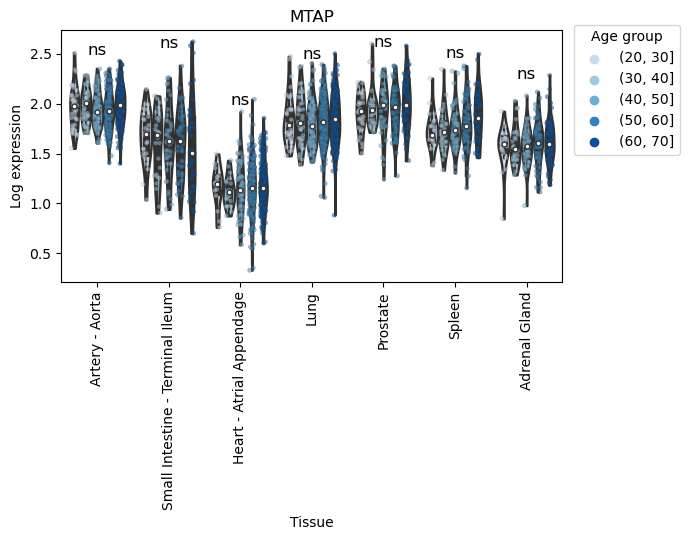

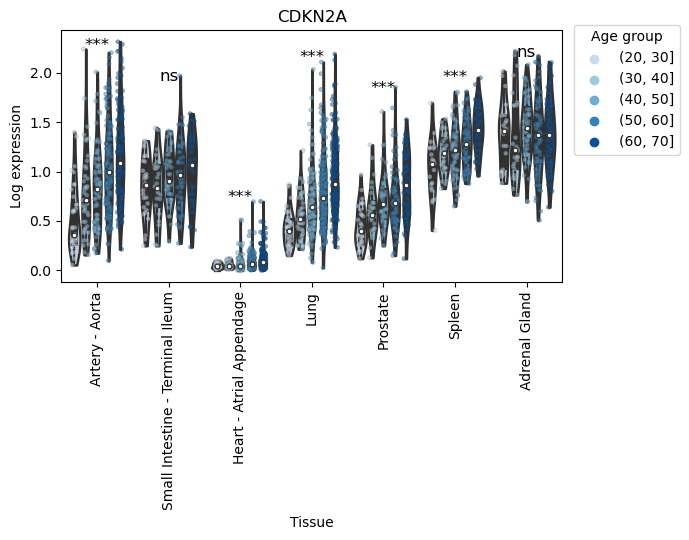

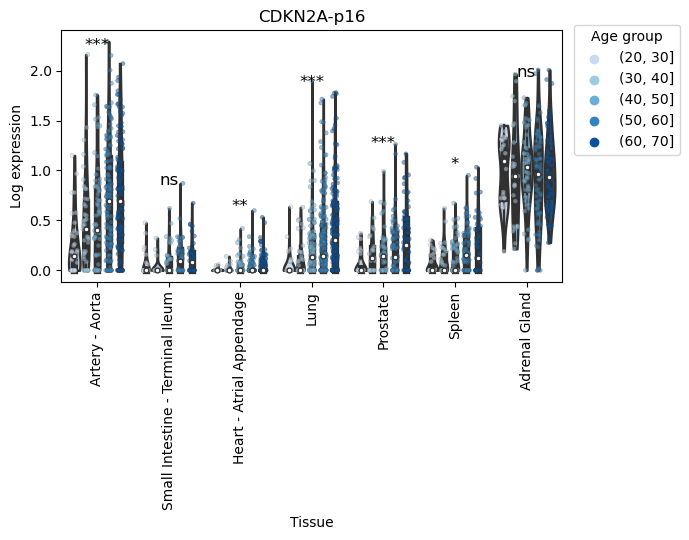

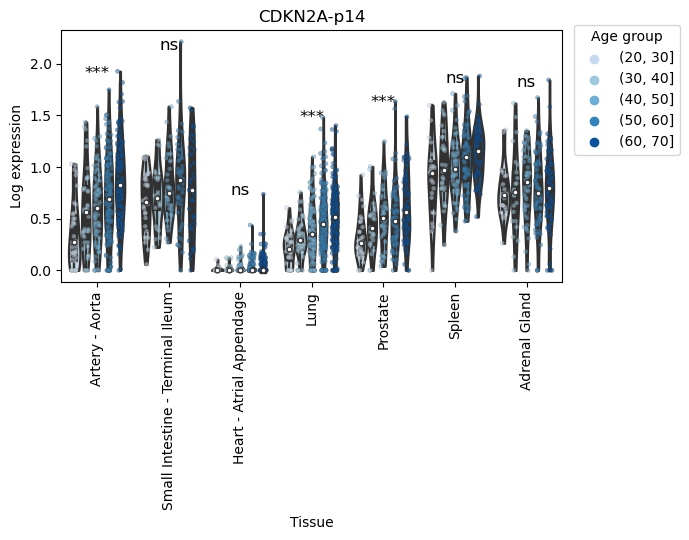

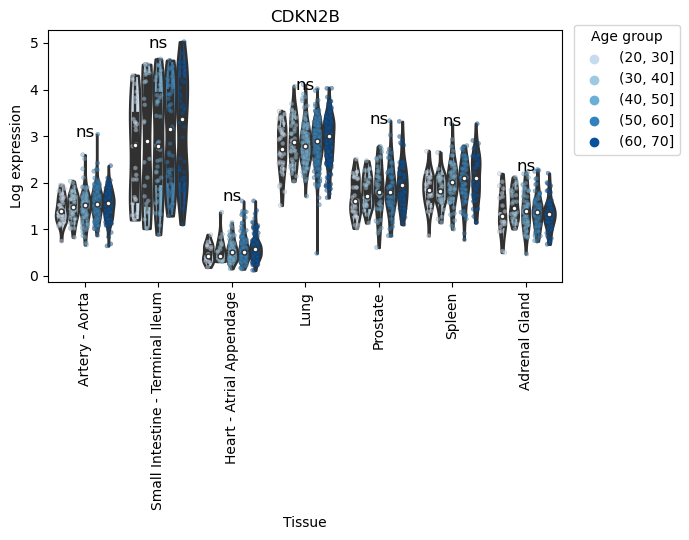

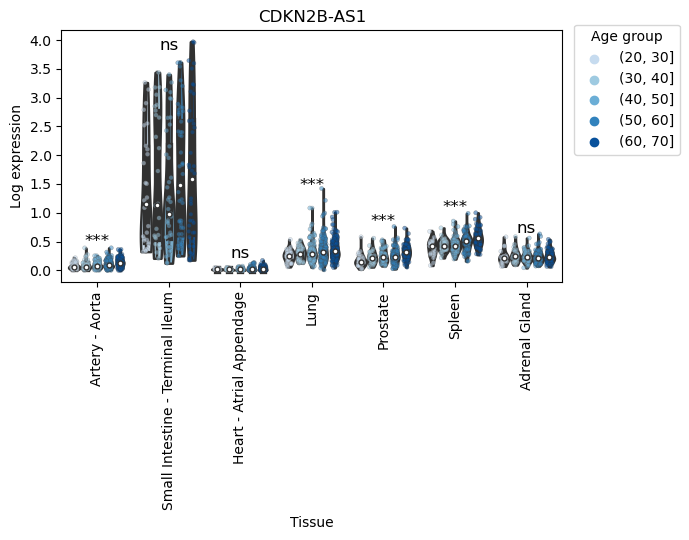

In [25]:
for this_gene in geneorder:
    nrows, ncols = 1, 1
    fig = plt.figure(figsize=(7, 5.5))
    ax = fig.add_subplot(1, 1, 1)
    
    temp = plot_df_subs4[plot_df_subs4.Gene == this_gene].copy()

    sns.stripplot(
        x="Tissue", y="log_expr", hue="Age_group", data=temp,
        order=supp_tissue, hue_order=ageorder, palette=mypalette1,
        jitter=0.2, size=3, dodge=True, alpha=0.5, linewidth=0.3,
        edgecolor="gray", ax=ax
    )

    sns.violinplot(
        x="Tissue", y="log_expr", hue="Age_group", data=temp,
        order=supp_tissue, hue_order=ageorder, palette=mypalette,
        dodge=True, cut=0, linewidth=1.75, alpha=0.01, ax=ax
    )

    # Annotate each tissue 
    for tissue in supp_tissue:
        temp_tissue = temp[temp["Tissue"] == tissue]
        row = results_df[
            (results_df["gene name"] == this_gene) &
            (results_df["tissue"] == tissue)
        ]

        pval = row["p_adj_bonferroni"].values[0]
        # Convert p-value to stars
        if pval < 0.001:
            star = "***"
        elif pval < 0.01:
            star = "**"
        elif pval < 0.05:
            star = "*"
        else:
            star = "ns"

        # x position = tissue index
        xpos = supp_tissue.index(tissue)

        # Place the star slightly below the maximum value
        ymax = temp_tissue["log_expr"].max()
        ymin = temp_tissue["log_expr"].min()
        offset = 0.05 * (ymax - ymin)  # 5% of the range
        y_pos = ymax - offset  # inside the box

        ax.text(xpos, y_pos, star, ha="center", va="bottom", fontsize=12, color="black")

    ax.set_title(this_gene)
    ax.set_ylabel("Log expression")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[:len(ageorder)],
        labels[:len(ageorder)],
        title="Age group",
        bbox_to_anchor=(1.01, 1.05),
        loc="upper left"
    )
    fig.tight_layout()
    plt.show()
    #fig.savefig(os.path.join('plots', "viostripplot_2groups_SuppT_" + this_gene +'_withStars_AllAgeGroups.pdf'), format='pdf')


In [26]:
import statsmodels
statsmodels.__version__

'0.13.5'

In [27]:
import scipy
scipy.__version__

'1.10.0'

In [28]:
sns.__version__

'0.12.2'